# Experiment 4: Threshold

In this experiment, we will use the best model (dual embeddings of the chunks and the metadata of the whole document) and find the optimal threshold for cosine similarity.

### 1. Implement the best retriever

In [ ]:
import json
from pathlib import Path
import fitz #pip install PyMuPDF
from embedder import Embedder
import numpy as np

In [ ]:
BASE_DIR = Path.cwd().parents[0]   # backend/
PDF_EXAMPLES = BASE_DIR/ "example_pdfs_to_upload"

DATA_DIR = BASE_DIR / "data"
META_CACHE_PATH = DATA_DIR / "llm_metadata_cache.json"
LLM_CHUNKS_PATH = DATA_DIR / "llm_database.json"

if not META_CACHE_PATH.exists():
    raise RuntimeError("llm_metadata_cache.json not found. Metadata must be precomputed.")

with META_CACHE_PATH.open("r", encoding="utf-8") as f:
    metadata_cache = json.load(f)

In [64]:
def build_metadata_string(llm_meta):

    if not llm_meta:
        return ""
    parts = []
    if llm_meta.get("title"):
        parts.append(f"Title: {llm_meta['title']}")
    if llm_meta.get("topics"):
        parts.append("Topics: " + ", ".join(llm_meta["topics"]))
    if llm_meta.get("keywords"):
        parts.append("Keywords: " + ", ".join(llm_meta["keywords"]))
    if llm_meta.get("one_sentence_summary"):
        parts.append("Summary: " + llm_meta["one_sentence_summary"])
    return "[METADATA]\n" + "\n".join(parts)

def get_llm_metadata(pdf_name: str) -> dict:
    """
    Read-only metadata accessor.
    No LLM calls. No side effects.
    """
    return metadata_cache.get(pdf_name, {})

In [65]:
class DataManager:
    """
    Handles:
    - PDF text extraction
    - Chunking
    - Embedding dual
    """

    def __init__(self, pdf_folder, llm_db_path = LLM_CHUNKS_PATH):
        self.embedder = Embedder()
        self.pdf_folder = pdf_folder
        self.tokenizer = self.embedder.model.tokenizer
        
        with open(llm_db_path, "r", encoding="utf-8") as f:
            llm_db = json.load(f)  

        self.llm_chunks_map = {
            d["pdf_name"]: d.get("chunks", [])  
            for d in llm_db
            if "pdf_name" in d}

    # ------------------------------
    # CHUNKING
    # ------------------------------
    def get_llm_chunks(self, pdf_name):
        chunks = self.llm_chunks_map.get(pdf_name, [])
        if not chunks:
            raise ValueError(f"No LLM chunks found for {pdf_name} in llm_database.json")
        return chunks

    # ------------------------------
    # MAIN PIPELINE
    # ------------------------------
    def process_pdf(self, pdf_path):
        chunks_from_json = self.get_llm_chunks(pdf_path.name)
        chunks = [c['text'] for c in chunks_from_json]

        llm_meta = get_llm_metadata(pdf_path.name)
        meta_str = build_metadata_string(llm_meta)
        emb_meta = self.embedder.encode(meta_str)

        chunk_records = []
        for chunk in chunks:
            emb_text = self.embedder.encode(chunk)
            chunk_records.append({
                "text": chunk,
                "embedding_text": emb_text,
                "embedding_meta": emb_meta
            })

        return {
            "pdf_name": pdf_path.name,
            "llm_metadata": llm_meta,
            "chunks": chunk_records}

    # ------------------------------
    # INDEX BUILDING
    # ------------------------------
    def build_index(self, pdf_paths):
        database = []

        for pdf_path in pdf_paths:
            entry = self.process_pdf(pdf_path)
            print(f"Indexed: {pdf_path.name}")
            database.append(entry)

        return database

In [ ]:
class BaselineRetriever:
    def __init__(self, database=None, embedder=None):
        self.embedder = embedder or Embedder()
        self.database = database or []

    def cosine_similarity(self, v1, v2):
        v1 = np.array(v1)
        v2 = np.array(v2)
        return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

    def search(self, query, threshold=0.70, alpha=0.7):
        query_emb = self.embedder.encode(query)
        results = []

        for entry in self.database:
            best_score = 0.0
            best_chunk = None

            for chunk in entry.get("chunks", []):
                s_text = self.cosine_similarity(query_emb, chunk["embedding_text"])
                s_meta = self.cosine_similarity(query_emb, chunk["embedding_meta"])
                score = alpha * s_text + (1 - alpha) * s_meta

                if score > best_score:
                    best_score = score
                    best_chunk = chunk

            if best_score >= threshold:
                results.append({
                    "paper_id": entry.get("pdf_name", ""),
                    "title": entry.get("llm_metadata", {}).get("title", entry.get("pdf_name", "")),
                    "pdf_name": entry.get("pdf_name", ""),
                    "score": round(best_score, 3),
                    "sample_text": best_chunk["text"][:300] if best_chunk else ""
                })

        results.sort(key=lambda x: x["score"], reverse=True)
        return results

In [67]:
embedder = Embedder()
dm = DataManager(pdf_folder=PDF_EXAMPLES)
pdf_paths = list(PDF_EXAMPLES.glob("*.pdf"))

final_model_db = dm.build_index(pdf_paths)
final_retriever = BaselineRetriever(final_model_db, embedder)

Indexed: 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf
Indexed: 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf
Indexed: 2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf
Indexed: 2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf
Indexed: 2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf
Indexed: 2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf
Indexed: 2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf
Indexed: 2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf
Indexed: 2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf
Indexed: 2025-12-04_Alice-Rober

### 2. Evaluation of the threshold

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

We use two different types of sets of evaluation pairs:
1. Positive examples: queries with the most relevant document they should retrieve
2. Negative examples: queries that should not return any document

In [69]:
from evaluation_queries import queries_easy, queries_intermediate, queries_difficult
from evaluation_queries import queries_negative_easy, queries_negative_intermediate, queries_negative_difficult

We use as metrics:
- Hit_rate@3
- False Positive Rate

In [70]:
def hit_at_k(results, target_doc, k=3):
    return int(any(r["pdf_name"] == target_doc for r in results[:k]))

In [71]:
def evaluate_query_set(retriever, queries, threshold, k=3):
    """
    queries:
      - positive: dict[query -> target_doc]
      - negative: dict[query -> None]
    """

    TP = FP = FN = TN = 0
    mrrs = []
    hits = []

    for query, target in queries.items():
        results = retriever.search(query, threshold=threshold)

        # Negative query
        if target is None:
            if len(results) > 0:
                FP += 1
            else:
                TN += 1
            continue

        # Positive query
        hit = hit_at_k(results, target, k)
        hits.append(hit)

        if hit == 1:
            TP += 1
        else:
            FN += 1

    return {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "MRR": sum(mrrs) / len(mrrs) if mrrs else 0.0,
        "Hit@3": sum(hits) / len(hits) if hits else 0.0,
        "Precision": TP / (TP + FP) if (TP + FP) else 0.0,
        "Recall": TP / (TP + FN) if (TP + FN) else 0.0,
        "FPR": FP / (FP + TN) if (FP + TN) else 0.0,
    }


In [72]:
def sweep_thresholds(retriever, thresholds, query_sets):
    rows = []
    for t in thresholds:
        if (t*100)%10 == 0:
            print(f"{int(t*100)}% processed...")
        for name, queries in query_sets.items():
            metrics = evaluate_query_set(retriever, queries, threshold=t)
            rows.append({
                "Threshold": t,
                "QuerySet": name,
                **metrics})
    return pd.DataFrame(rows)

#### 2.1 Success versus threshold

We define success with Hit@3 for positive queries, and FPR = 0 for negative queries:
- **TP**: the correct document is retrieved in the first 3 positions (Hit@3)
- **FN**: the correct document is not retrieved in the first 3 positions (Hit@3)
- **FP**: a document is retrieved 
- **TN**: no document is retrieved

In [73]:
query_sets = {
    "Positive easy": queries_easy,
    "Positive intermediate": queries_intermediate,
    "Positive difficult": queries_difficult,
    "Negative easy": queries_negative_easy,
    "Negative intermediate": queries_negative_intermediate,
    "Negative difficult": queries_negative_difficult}

thresholds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]

df_metrics = sweep_thresholds(final_retriever, thresholds, query_sets)

0% processed...
10% processed...
20% processed...
30% processed...
40% processed...
50% processed...
60% processed...
70% processed...
80% processed...
90% processed...
100% processed...


In [74]:
def threshold_selection_plot(threshold_list, df, positive=True):

    plt.figure(figsize=(10, 6))

    for t in threshold_list:
        plt.axvline(x=t, color="lightgray", linewidth=0.8, alpha=0.7)
        
    # Positive queries: correct doc in top-3
    for name in ["Positive easy", "Positive intermediate", "Positive difficult"]:
        subset = df[df["QuerySet"] == name]
        plt.plot(subset["Threshold"], subset["Hit@3"], label=f"{name} Hit@3")

    # Negative queries: nothing retrieved
    for name in ["Negative easy", "Negative intermediate", "Negative difficult"]:
        neg = df[df["QuerySet"] == name]
        if positive:
            plt.plot(neg["Threshold"], neg["FPR"], label=f"{name} retrieved rate")
            plt.ylabel("Score")
        else:
            plt.plot(neg["Threshold"], 1 - neg["FPR"], label=f"{name} not retrieved")
            plt.ylabel("Correctness (1 = correct behavior)")

    plt.xlabel("Cosine Similarity Threshold")
    plt.title("Threshold vs Correct Retrieval Behavior")
    plt.legend()
    plt.grid(True)
    plt.show()

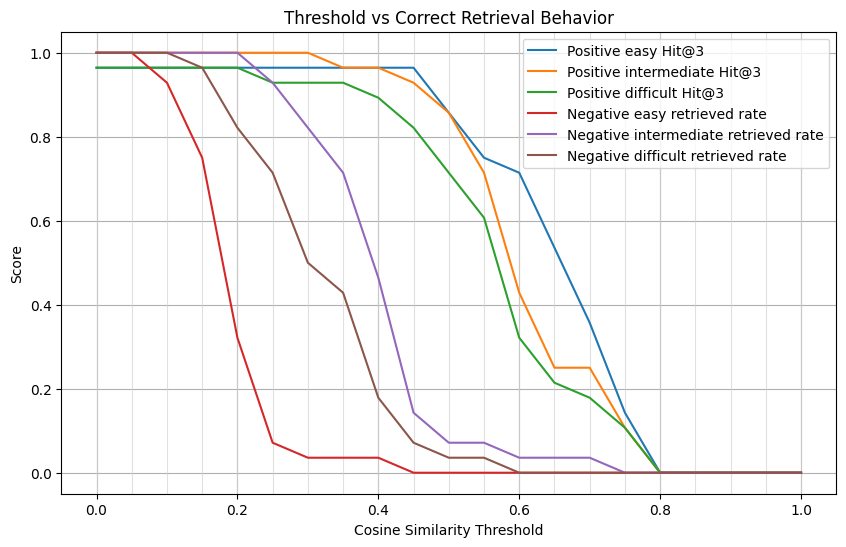

In [75]:
threshold_selection_plot(thresholds, df_metrics)

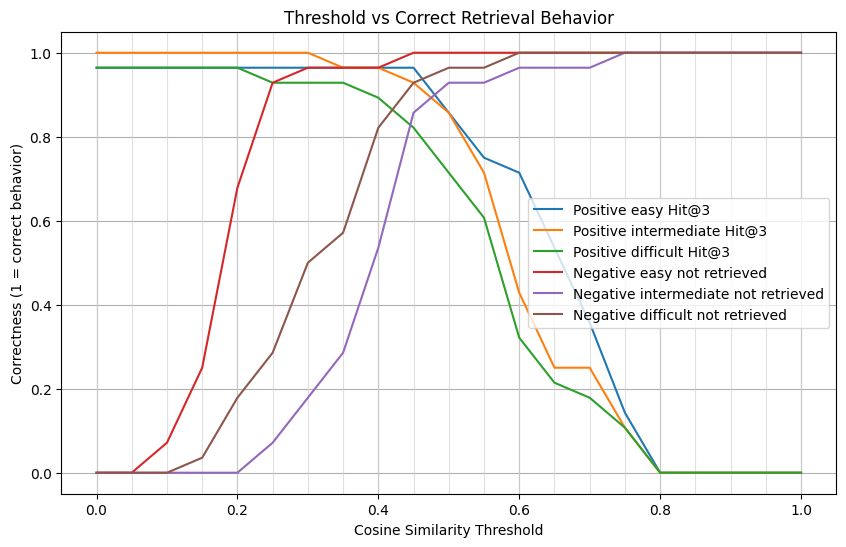

In [76]:
threshold_selection_plot(thresholds, df_metrics, False)

#### 2.2 We evaluate the final model with a confusion matrix

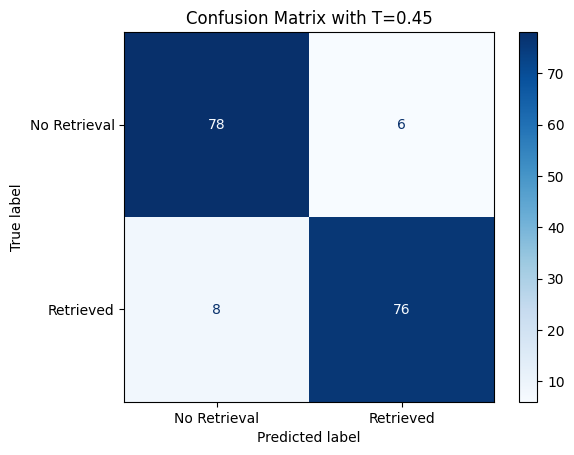

In [77]:
best_threshold = 0.45
subset = df_metrics[df_metrics["Threshold"] == best_threshold]

TP = int(subset["TP"].sum())
FP = int(subset["FP"].sum())
FN = int(subset["FN"].sum())
TN = int(subset["TN"].sum())

cm = np.array([[TN, FP],
               [FN, TP]])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Retrieval", "Retrieved"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix with T={best_threshold}")
plt.show()